In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
from tqdm import tqdm

In [2]:
torch.manual_seed(0)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
def sample_gmm(n, means, weights, sigmas, device):
    means = torch.tensor(means, dtype=torch.float32, device=device)
    weights = torch.tensor(weights, dtype=torch.float32, device=device)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)
    idx = torch.multinomial(weights, n, replacement=True)
    x = torch.randn(n, device=device) * sigmas[idx] + means[idx] #generate samples
    return x.unsqueeze(-1)

In [5]:
def median_heuristic(X):
    if X.dim() == 1:
        X = X.reshape(-1, 1)
    dists_sq = torch.cdist(X,X, p=2) ** 2
    H_n = torch.median(dists_sq)
    h = torch.sqrt(H_n / 2.0)
    return h

In [6]:
class PooledKSD:
    def __init__(self, means, sigmas, weights, device, model=None, ):
        self.device = device

        self.means = torch.as_tensor(means, dtype=torch.float32, device=device)
        self.sigmas = torch.as_tensor(sigmas, dtype=torch.float32, device=device)
        self.weights = torch.as_tensor(weights, dtype=torch.float32, device=device)

        self.model = model
        self.use_denoiser = model is not None

        # setting denoiser to eval mode
        if self.use_denoiser:
            self.model.eval()

    def score_function(self, x, sigma_noise):
        # estimated score
        if self.use_denoiser:
            original_shape = x.shape
            x_flat = x.reshape(-1, x.shape[-1])
            sigma = torch.full_like(x_flat, sigma_noise)
            with torch.no_grad():
                score = self.model(x_flat, sigma)
            return score.reshape(original_shape)
        else:
            # analytic true score
            x_in = x.clone().detach().requires_grad_(True)
            x_flat = x_in.reshape(-1, x_in.shape[-1])

            means = self.means.view(1, -1)
            sigmas = self.sigmas.view(1, -1)
            weights = self.weights.view(1, -1)
            var = sigmas**2 + sigma_noise**2

            log_components = (torch.log(weights) - 0.5 * torch.log(2 * torch.pi * var) -
                             (x_flat - means)**2 / (2 * var))
            logp = torch.logsumexp(log_components, dim=1)
            score = torch.autograd.grad(logp.sum(), x_in, create_graph=True)[0]
            return score

    def rbf_kernel(self, x1, x2, scale):
        diff = x1 - x2
        return torch.exp(-(diff**2).sum(dim=-1) /(2*scale**2))
    def grad_x1_rbf(self, x1, x2, scale):
        k = self.rbf_kernel(x1, x2, scale)
        return ( -k.unsqueeze(-1)* (x1-x2) / scale**2)
    def grad_x2_rbf(self, x1, x2, scale):
        return -self.grad_x1_rbf( x1, x2, scale)

    def grad_x1_x2_rbf(self, x1, x2, scale):
        diff = x1-x2
        sq = (diff**2).sum(dim=-1)
        k = self.rbf_kernel(x1,x2,scale)
        d = diff.shape[-1]
        return (d/scale**2 -  sq/scale**4)*k

    def u_q(self, x1, x2,scale,sigma_l):
        score1 = self.score_function(x1, sigma_l)
        score2 = self.score_function(x2, sigma_l)
        k = self.rbf_kernel(x1,x2,scale)
        grad1 = self.grad_x1_rbf(x1,x2,scale)
        grad2 = self.grad_x2_rbf( x1,x2,scale)
        grad12 = self.grad_x1_x2_rbf(x1,x2,scale)
        return ((score1*score2).sum(dim=-1)*k + (score1*grad2).sum(dim=-1) + (grad1*score2).sum(dim=-1) + grad12)

    def bootstrap_stat(self, U):
        n = U.shape[0]
        probs = torch.ones(n, device=self.device) / n
        samples = torch.multinomial(probs, num_samples=n, replacement=True)
        w = torch.bincount(samples, minlength=n).float()
        w_centered = (w / n) - (1.0 / n)
        S = w_centered @ U @ w_centered
        diag_correction = torch.sum(w_centered ** 2 * torch.diag(U))
        return S - diag_correction

    def compute_ksd(self, samples, scale):
        samples = samples.to(self.device)
        n = samples.shape[0]
        x_i = samples[:, None, :]
        x_j = samples[None, :, :]
        U = self.u_q(x_i, x_j, scale)
        total = U.sum() - torch.diagonal(U).sum()
        ksd = total / (n * (n - 1))
        return ksd, U

    def pooled_test(self, x_ksd, sigma_list, alpha=0.05, num_boot=300):
        n = x_ksd.shape[0]
        U = torch.zeros((n, n), device=x_ksd.device)
        for sigma_l in sigma_list:
            epsilon = torch.randn_like(x_ksd)
            x_i_tilde = x_ksd + sigma_l * epsilon
            x1 = x_i_tilde[:, None, :]
            x2 = x_i_tilde[None, :, :]
            scale = median_heuristic(x_ksd)
            scale = torch.clamp(scale, min=1e-3)
            U += self.u_q(x1, x2, scale, sigma_l)
        total = U.sum() - torch.diagonal(U).sum()
        ksd = total / (n * (n - 1))
        boot_stats = torch.stack([self.bootstrap_stat(U) for _ in range(num_boot)])
        critical_val = torch.quantile(boot_stats, 1 - alpha)
        reject = (ksd > critical_val).int()
        return reject, ksd, critical_val, boot_stats


100%|██████████| 100/100 [01:01<00:00,  1.64it/s]
/tmp/ipykernel_632/1787536048.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


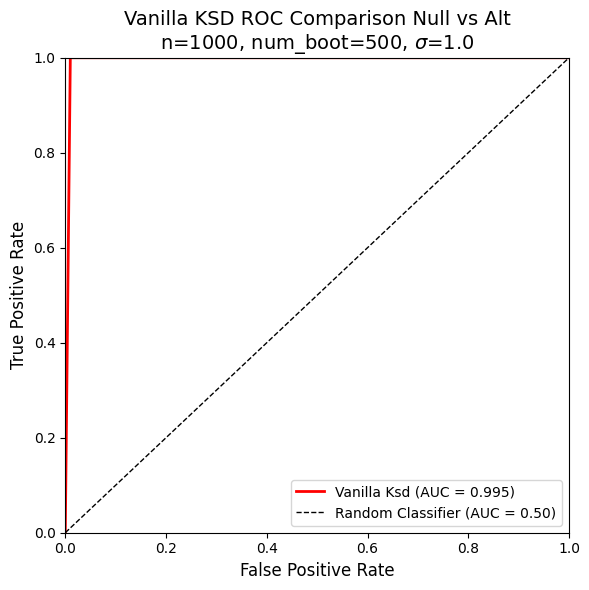

In [7]:
n = 1000
delta = 1.0
sigma = 1.0
num_boot = 500
n_trials = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pksd = PooledKSD(means=[0],sigmas=[sigma],weights=[1],device=device,model=None)

results = {
    'vanilla_ksd': {'p_null': [], 'p_alt': []}
}

for trial in tqdm(range(n_trials)):
    # Sample null
    x_null = sample_gmm(n, means=[0], sigmas=[sigma],
                        weights=[1], device=device)
    x_alt = sample_gmm(n, means=[1], sigmas=[sigma], weights=[1], device=device)

    # null hypothesis
    scale_null = median_heuristic(x_null)
    scale_null = torch.clamp(scale_null, min=1e-3)

    # U Matrix
    U_null = pksd.u_q(
        x1=x_null[:, None, :],
        x2=x_null[None, :, :],
        scale=scale_null,
        sigma_l=0.0
    )
    ksd_null = (U_null.sum() - torch.diagonal(U_null).sum()) / (n * (n - 1))

    # Bootstrap for null
    boot_stats_null = torch.stack([pksd.bootstrap_stat(U_null) for _ in range(num_boot)])
    p_null = (boot_stats_null >= ksd_null).float().mean().item()
    results['vanilla_ksd']['p_null'].append(p_null)

    # Alternate hypothesis
    scale_alt = median_heuristic(x_alt)
    scale_alt = torch.clamp(scale_alt, min=1e-3)

    U_alt = pksd.u_q(
        x1=x_alt[:, None, :],
        x2=x_alt[None, :, :],
        scale=scale_alt,
        sigma_l=0.0
    )
    ksd_alt = (U_alt.sum() - torch.diagonal(U_alt).sum()) / (n * (n - 1))
    boot_stats_alt = torch.stack([pksd.bootstrap_stat(U_alt) for _ in range(num_boot)])
    p_alt = (boot_stats_alt >= ksd_alt).float().mean().item()
    results['vanilla_ksd']['p_alt'].append(p_alt)

# Plot ROC curves
plt.figure(figsize=(6, 6))

for method, data in results.items():
    p_null = np.array(data['p_null'])
    p_alt = np.array(data['p_alt'])

    thresholds = np.linspace(0, 1, 100)
    fpr = [np.mean(p_null < t) for t in thresholds]
    tpr = [np.mean(p_alt < t) for t in thresholds]
    auc = np.trapz(tpr, fpr)

    label = f'{method.replace("_", " ").title()} (AUC = {auc:.3f})'
    color = 'red'
    plt.plot(fpr, tpr, linewidth=2, color=color, label=label)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(f"Vanilla KSD ROC Comparison Null vs Alt\nn={n}, num_boot={num_boot}, $\\sigma$={sigma}", fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(False)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('vanilla_ksd_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Testing delta = 0.0


100%|██████████| 100/100 [00:51<00:00,  1.94it/s]
/tmp/ipykernel_632/1909479909.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_value = np.trapz(tpr, fpr)


AUC Value = 0.51605
Testing delta = 0.2


100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


AUC Value = 0.9832
Testing delta = 0.4


...

AUC Value = 0.985
Testing delta = 0.8


100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


AUC Value = 0.9750000000000001
Testing delta = 1


100%|██████████| 100/100 [00:50<00:00,  1.97it/s]


AUC Value = 1.0


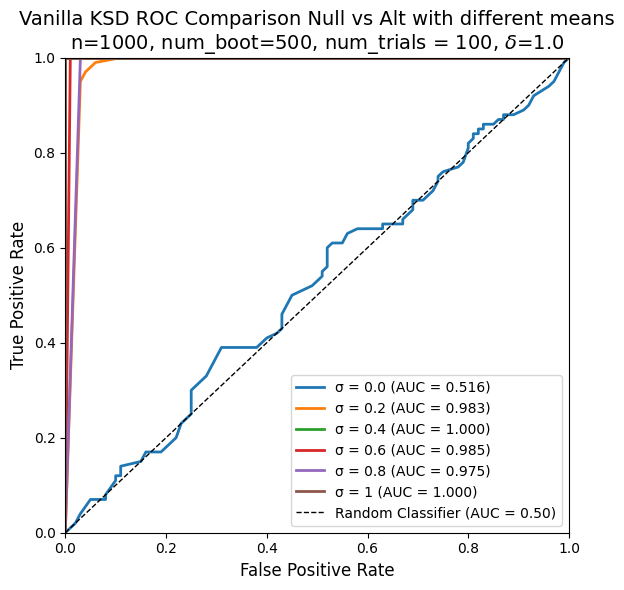

In [8]:
#@title mean perturbation
n = 1000
delta = 1.0
sigma = 1.0
num_boot = 500
n_trials = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pksd = PooledKSD(means=[0],sigmas=[sigma],weights=[1],device=device,model=None)

delta_list = [0.0, 0.20, 0.4, 0.6, 0.8, 1]
results = {}

# Plot ROC curves
plt.figure(figsize=(6, 6))

for delta in delta_list:
    print(f"Testing delta = {delta}")
    p_values_null = []
    p_values_alt = []
    for trial in tqdm(range(n_trials)):
        # Sample null
        x_null = sample_gmm(n, means=[0], sigmas=[sigma],weights=[1], device=device)
        x_alt = sample_gmm(n, means=[delta], sigmas=[sigma], weights=[1], device=device)
        # null hypothesis
        scale_null = median_heuristic(x_null)
        scale_null = torch.clamp(scale_null, min=1e-3)
        # U Matrix
        U_null = pksd.u_q( x1=x_null[:, None, :], x2=x_null[None, :, :], scale=scale_null, sigma_l=0.0)
        ksd_null = (U_null.sum() - torch.diagonal(U_null).sum()) / (n * (n - 1))
        # Bootstrap for null
        boot_stats_null = torch.stack([pksd.bootstrap_stat(U_null) for _ in range(num_boot)])
        p_null = (boot_stats_null >= ksd_null).float().mean().item()
        p_values_null.append(p_null)

        # Alternate hypothesis
        scale_alt = median_heuristic(x_alt)
        scale_alt = torch.clamp(scale_alt, min=1e-3)

        U_alt = pksd.u_q(x1=x_alt[:, None, :],x2=x_alt[None, :, :],scale=scale_alt,sigma_l=0.0)
        ksd_alt = (U_alt.sum() - torch.diagonal(U_alt).sum()) / (n * (n - 1))
        boot_stats_alt = torch.stack([pksd.bootstrap_stat(U_alt) for _ in range(num_boot)])
        p_alt = (boot_stats_alt >= ksd_alt).float().mean().item()
        p_values_alt.append(p_alt)

    p_null = np.array(p_values_null)
    p_alt = np.array(p_values_alt)
    thresholds = np.linspace(0, 1, 100)
    fpr = [np.mean(p_null < t) for t in thresholds]
    tpr = [np.mean(p_alt < t) for t in thresholds]
    auc_value = np.trapz(tpr, fpr)
    print(f"AUC Value = {auc_value}")
    plt.plot(fpr, tpr, linewidth=2, label=f'σ = {delta} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(f"Vanilla KSD ROC Comparison Null vs Alt with different means\nn={n}, num_boot={num_boot}, num_trials = {n_trials}, $\\delta$={sigma}", fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(False)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('vanilla_ksd_roc_comparison_different_deltas.png', dpi=300, bbox_inches='tight')
plt.show()

Testing sigma = 0.5


100%|██████████| 100/100 [00:50<00:00,  1.96it/s]
/tmp/ipykernel_632/3152628227.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_value = np.trapz(tpr, fpr)


AUC Value = 0.995
Testing sigma = 0.75


100%|██████████| 100/100 [00:50<00:00,  1.99it/s]


AUC Value = 0.9950000000000001
Testing sigma = 1.0


...

AUC Value = 0.9950000000000001
Testing sigma = 1.5


100%|██████████| 100/100 [00:49<00:00,  2.01it/s]


AUC Value = 0.99
Testing sigma = 1.75


100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


AUC Value = 0.985


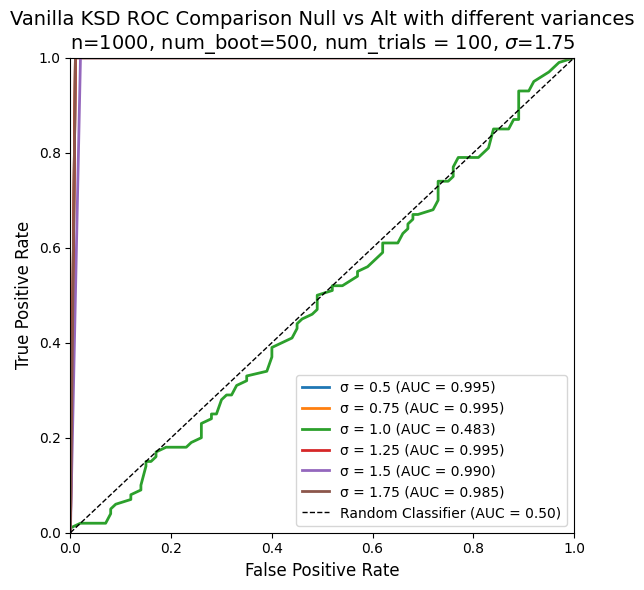

In [12]:
#@title variance perturbation
n = 1000
delta = 1.0
sigma = 1.0
num_boot = 500
n_trials = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pksd = PooledKSD(means=[0],sigmas=[1],weights=[1],device=device,model=None)

sigma_list = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75]
results = {}

# Plot ROC curves
plt.figure(figsize=(6, 6))

for sigma in sigma_list:
    print(f"Testing sigma = {sigma}")
    p_values_null = []
    p_values_alt = []
    for trial in tqdm(range(n_trials)):
        # Sample null
        x_null = sample_gmm(n, means=[0], sigmas=[1],weights=[1], device=device)
        x_alt = sample_gmm(n, means=[0], sigmas=[sigma], weights=[1], device=device)
        # null hypothesis
        scale_null = median_heuristic(x_null)
        scale_null = torch.clamp(scale_null, min=1e-3)
        # U Matrix
        U_null = pksd.u_q( x1=x_null[:, None, :], x2=x_null[None, :, :], scale=scale_null, sigma_l=0.0)
        ksd_null = (U_null.sum() - torch.diagonal(U_null).sum()) / (n * (n - 1))
        # Bootstrap for null
        boot_stats_null = torch.stack([pksd.bootstrap_stat(U_null) for _ in range(num_boot)])
        p_null = (boot_stats_null >= ksd_null).float().mean().item()
        p_values_null.append(p_null)

        # Alternate hypothesis
        scale_alt = median_heuristic(x_alt)
        scale_alt = torch.clamp(scale_alt, min=1e-3)

        U_alt = pksd.u_q(x1=x_alt[:, None, :],x2=x_alt[None, :, :],scale=scale_alt,sigma_l=0.0)
        ksd_alt = (U_alt.sum() - torch.diagonal(U_alt).sum()) / (n * (n - 1))
        boot_stats_alt = torch.stack([pksd.bootstrap_stat(U_alt) for _ in range(num_boot)])
        p_alt = (boot_stats_alt >= ksd_alt).float().mean().item()
        p_values_alt.append(p_alt)

    p_null = np.array(p_values_null)
    p_alt = np.array(p_values_alt)
    thresholds = np.linspace(0, 1, 100)
    fpr = [np.mean(p_null < t) for t in thresholds]
    tpr = [np.mean(p_alt < t) for t in thresholds]
    auc_value = np.trapz(tpr, fpr)
    print(f"AUC Value = {auc_value}")
    plt.plot(fpr, tpr, linewidth=2, label=f'σ = {sigma} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(f"Vanilla KSD ROC Comparison Null vs Alt with different variances\nn={n}, num_boot={num_boot}, num_trials = {n_trials}, $\\sigma$={sigma}", fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(False)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('vanilla_ksd_roc_comparison_different_sigmas.png', dpi=300, bbox_inches='tight')
plt.show()


Testing delta = 0.25
Sample Size n = 25


Error rate e = 0.475
Sample Size n = 50


Error rate e = 0.48500000000000004
Sample Size n = 75


Error rate e = 0.4
Sample Size n = 100


Error rate e = 0.36
Sample Size n = 150


...

Error rate e = 0.035
Sample Size n = 300


Error rate e = 0.02
Sample Size n = 500


Error rate e = 0.025
Sample Size n = 750


Error rate e = 0.02
Sample Size n = 1000


Error rate e = 0.03


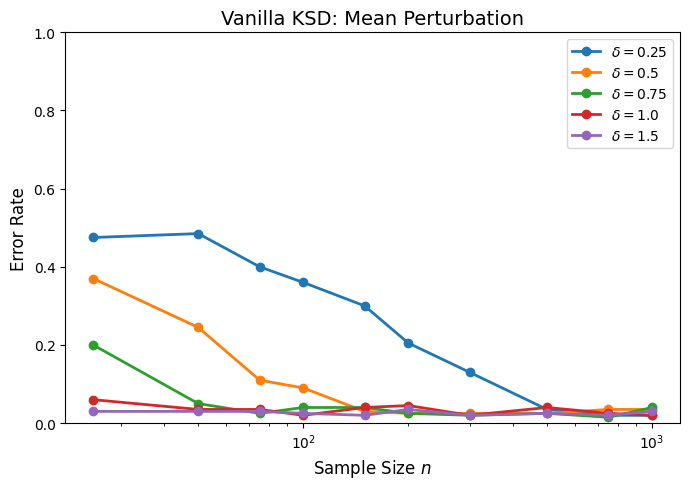

In [13]:
#@title Vanilla KSD - Mean Perturbation Error Rate

n_list = [25, 50, 75, 100, 150, 200, 300, 500, 750, 1000]
delta_list = [0.25, 0.5, 0.75, 1.0, 1.5]
n = 1000
num_boot = 500
n_trials = 100
alpha = 0.05

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reference distribution
pksd = PooledKSD(means=[0],sigmas=[1],weights=[1],device=device,model=None)

results = {}

for delta in delta_list:
    print(f"\nTesting delta = {delta}")
    error_rates = []
    for n in n_list:
        type1_errors = []
        type2_errors = []
        print(f"Sample Size n = {n}")
        for trial in tqdm(range(n_trials), leave=False):
            # NULL DATA
            x_null = sample_gmm(n, means=[0],sigmas=[1],weights=[1],device=device)
            x_alt = sample_gmm(n,means=[delta], sigmas=[1],weights=[1],device=device)
            scale_null = median_heuristic(x_null)
            scale_null = torch.clamp(scale_null, min=1e-3)
            U_null = pksd.u_q(x1=x_null[:, None, :],x2=x_null[None, :, :],scale=scale_null,sigma_l=0.0)
            ksd_null = (U_null.sum() - torch.diagonal(U_null).sum()) / (n * (n - 1))
            # Bootstrap null distribution
            boot_stats_null = torch.stack([pksd.bootstrap_stat(U_null) for _ in range(num_boot)])
            p_null = ((boot_stats_null >= ksd_null).float().mean().item())
            # Type-I error:
            # reject H0 even though H0 is true
            type1_errors.append(p_null < alpha)

            # ALTERNATIVE DATA
            scale_alt = median_heuristic(x_alt)
            scale_alt = torch.clamp(scale_alt, min=1e-3)
            U_alt = pksd.u_q(x1=x_alt[:, None, :], x2=x_alt[None, :, :], scale=scale_alt, sigma_l=0.0)
            ksd_alt = (U_alt.sum() - torch.diagonal(U_alt).sum()) / (n * (n - 1))
            # Bootstrap null distribution for the test statistic
            boot_stats_alt = torch.stack([pksd.bootstrap_stat(U_alt) for _ in range(num_boot)])
            p_alt = ((boot_stats_alt >= ksd_alt).float().mean().item())
            # Type-II error: fail to reject H0 even though H1 is true
            type2_errors.append(p_alt >= alpha)
        # Error rates for this n
        type1_rate = np.mean(type1_errors)
        type2_rate = np.mean(type2_errors)
        # Equal probability of H0 and H1
        error_rate = 0.5 * (type1_rate + type2_rate)
        print(f"Error rate e = {error_rate}")
        error_rates.append(error_rate)
    results[delta] = error_rates
# Plot
plt.figure(figsize=(7, 5))
for delta in delta_list:
    plt.plot(n_list,results[delta],marker='o',linewidth=2,
        label=fr'$\delta={delta}$')
plt.xlabel("Sample Size $n$", fontsize=12)
plt.ylabel("Error Rate", fontsize=12)
plt.title("Vanilla KSD: Mean Perturbation",fontsize=14)
plt.legend()
plt.grid(False)
plt.xscale('log')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('vanilla_ksd_mean_perturbation_error_rate.png',dpi=300,bbox_inches='tight')
plt.show()


Testing delta = 0.5
Sample Size n = 25


Error rate e = 0.405
Sample Size n = 50


Error rate e = 0.095
Sample Size n = 75


Error rate e = 0.025
Sample Size n = 100


Error rate e = 0.01
Sample Size n = 150


...

Error rate e = 0.02
Sample Size n = 300


Error rate e = 0.035
Sample Size n = 500


Error rate e = 0.02
Sample Size n = 750


Error rate e = 0.02
Sample Size n = 1000


Error rate e = 0.035


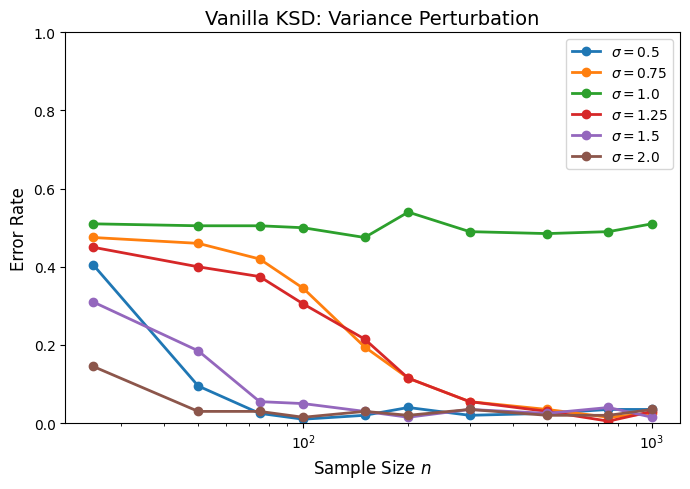

In [14]:
#@title Vanilla KSD - Variance Perturbation Error Rate

n_list = [25, 50, 75, 100, 150, 200, 300, 500, 750, 1000]
sigma_list = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0] #
n = 1000
num_boot = 500
n_trials = 100
alpha = 0.05

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reference distribution
pksd = PooledKSD(means=[0],sigmas=[1],weights=[1],device=device,model=None)

results = {}

for sigma in sigma_list:
    print(f"\nTesting delta = {sigma}")
    error_rates = []
    for n in n_list:
        type1_errors = []
        type2_errors = []
        print(f"Sample Size n = {n}")
        for trial in tqdm(range(n_trials), leave=False):
            # NULL DATA
            x_null = sample_gmm(n, means=[0],sigmas=[1],weights=[1],device=device)
            x_alt = sample_gmm(n,means=[0], sigmas=[sigma],weights=[1],device=device)
            scale_null = median_heuristic(x_null)
            scale_null = torch.clamp(scale_null, min=1e-3)
            U_null = pksd.u_q(x1=x_null[:, None, :],x2=x_null[None, :, :],scale=scale_null,sigma_l=0.0)
            ksd_null = (U_null.sum() - torch.diagonal(U_null).sum()) / (n * (n - 1))
            # Bootstrap null distribution
            boot_stats_null = torch.stack([pksd.bootstrap_stat(U_null) for _ in range(num_boot)])
            p_null = ((boot_stats_null >= ksd_null).float().mean().item())
            # Type-I error:
            # reject H0 even though H0 is true
            type1_errors.append(p_null < alpha)

            # ALTERNATIVE DATA
            scale_alt = median_heuristic(x_alt)
            scale_alt = torch.clamp(scale_alt, min=1e-3)
            U_alt = pksd.u_q(x1=x_alt[:, None, :], x2=x_alt[None, :, :], scale=scale_alt, sigma_l=0.0)
            ksd_alt = (U_alt.sum() - torch.diagonal(U_alt).sum()) / (n * (n - 1))
            # Bootstrap null distribution for the test statistic
            boot_stats_alt = torch.stack([pksd.bootstrap_stat(U_alt) for _ in range(num_boot)])
            p_alt = ((boot_stats_alt >= ksd_alt).float().mean().item())
            # Type-II error: fail to reject H0 even though H1 is true
            type2_errors.append(p_alt >= alpha)
        # Error rates for this n
        type1_rate = np.mean(type1_errors)
        type2_rate = np.mean(type2_errors)
        # Equal probability of H0 and H1
        error_rate = 0.5 * (type1_rate + type2_rate)
        print(f"Error rate e = {error_rate}")
        error_rates.append(error_rate)
    results[sigma] = error_rates
# Plot
plt.figure(figsize=(7, 5))
for sigma in sigma_list:
    plt.plot(n_list,results[sigma],marker='o',linewidth=2,
        label=fr'$\sigma={sigma}$')
plt.xlabel("Sample Size $n$", fontsize=12)
plt.ylabel("Error Rate", fontsize=12)
plt.title("Vanilla KSD: Variance Perturbation",fontsize=14)
plt.legend()
plt.grid(False)
plt.xscale('log')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('vanilla_ksd_variance_perturbation_error_rate.png',dpi=300,bbox_inches='tight')
plt.show()